In [16]:
from tqdm import tqdm
import subprocess
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

In [37]:
def chunk_train(cert_train, cert_train_chunks):
    # Make the Train chunks
    with open(cert_train, "r") as train_in, open(cert_train_chunks, "w") as train_out:
        train_lines = train_in.readlines()
        for line in train_lines:
            line_clean = line.strip()
            if len(line_clean) < n:
                pass
            else:
                for i in range(len(line_clean) - n + 1):
                    train_out.write(line_clean[i:i+n] + "\n")    

def chunk_train_unique(cert_train_chunks, cert_train_unique_chunks):
    # Make unique Train Chunks
    with open(cert_train_chunks, "r") as chunks_in, open(cert_train_unique_chunks, "w") as chunks_out:
        in_chunks = chunks_in.readlines()
        unique_chunks = set()
        for chunk in in_chunks:
            unique_chunks.add(chunk)
        for chunk in unique_chunks:
            chunks_out.write(chunk)

def chunk_test(cert1_lines, cert1_chunks, cert1_mapping):
    # Make the Test Chunks
    with open(cert1_lines, "r") as input_file:
        with open(cert1_chunks, "w") as chunk_file:
            with open(cert1_mapping, "w") as mapping_file:
                syscall_lines = input_file.readlines()
                for line_idx in range(len(syscall_lines)):
                    syscall = syscall_lines[line_idx].strip()
                    label = syscall_lines[line_idx].strip()

                    if len(syscall) < n:
                        pass
                    else:
                        for i in range(len(syscall) - n + 1):
                            chunk_file.write(syscall[i:i+n] + "\n")
                            mapping_file.write(str(line_idx) + "\n")

def get_scores(n, r, cert1_alphabet, cert_train_unique_chunks, cert1_chunks, cert1_mapping, cert1_labels):
    # Get The Scores 
    cmd = [
        "java", "-jar", "negsel2.jar",
        "-alphabet", f"{cert1_alphabet}",
        "-self", f"{cert_train_unique_chunks}", 
        "-n", str(n), 
        "-r", str(r), 
        "-c", "-l",   
    ]
    results = []
    with open(cert1_chunks, 'r') as test_chunks, open(cert1_mapping, "r") as test_mapping, open(cert1_labels, "r") as labels_file:
        input_lines = test_chunks.readlines()
        mapping_lines = test_mapping.readlines()
        labels = labels_file.readlines()
    
        current_chunks = []
        current_mapping = "0"
        for i in tqdm(range(len(input_lines))):
            map_idx = mapping_lines[i].split("\n")[0]
            input_line = input_lines[i].split("\n")[0]
            if current_mapping == map_idx:
                current_chunks.append(input_line)
            else:
                result = subprocess.run(cmd, input="\n".join(current_chunks), capture_output=True, text=True)
                scores = np.array([float(s) for s in result.stdout.split("\n") if len(s) > 0])
                avg_score = np.mean(scores)
                label = int(labels[int(current_mapping)].split("\n")[0])
                results.append((avg_score,label))

                current_chunks = [input_line]
                current_mapping = map_idx
    return results

In [38]:
def pipeline(n, r, params):
    cert_train = params['train']
    cert_train_chunks = params['train_chunks']
    cert_train_unique_chunks = params['train_chunks_unique']
    cert1_lines = params['test']
    cert1_chunks = params['chunks'] 
    cert1_mapping = params['mapping'] 
    cert1_alphabet = params['abc']
    cert1_labels = params['labels']

    chunk_train(cert_train, cert_train_chunks)
    chunk_train_unique(cert_train_chunks, cert_train_unique_chunks)
    chunk_test(cert1_lines, cert1_chunks, cert1_mapping)
    return get_scores(n, r, cert1_alphabet, cert_train_unique_chunks, cert1_chunks, cert1_mapping, cert1_labels)

# Single Parameter Run

In [ ]:
###########################################################################################################
###########################################################################################################
# -------------------------------------------- CHANGE THIS ONLY -------------------------------------------

# can be 'cert' or 'unm'
data_type = 'cert' 

# can be '1', '2' or '3'
data_num = '1' 

# choose such that R <= N
N = 8
R = 3

###########################################################################################################
###########################################################################################################

parameters = {
    'train': f"syscalls/snd-{data_type}/snd-{data_type}.train",
    'train_chunks': f"snd_{data_type}_train_chunks_N_{N}_R_{R}.txt",
    'train_chunks_unique': f"snd_{data_type}_train_unique_chunks_N_{N}_R_{R}.txt",
    'labels': f"syscalls/snd-{data_type}/snd-{data_type}.{data_num}.labels",
    'test': f"syscalls/snd-{data_type}/snd-{data_type}.{data_num}.test",
    'abc': f"file://syscalls/snd-{data_type}/snd-{data_type}.alpha",
    'chunks': f"snd_{data_type}_test{data_num}_chunks_N_{N}_R_{R}.txt",
    'mapping': f"snd_{data_type}_test{data_num}_mapping_N_{N}_R_{R}.txt"
}

In [43]:
results = pipeline(N, R, parameters)

100%|██████████| 45508/45508 [01:14<00:00, 607.61it/s]


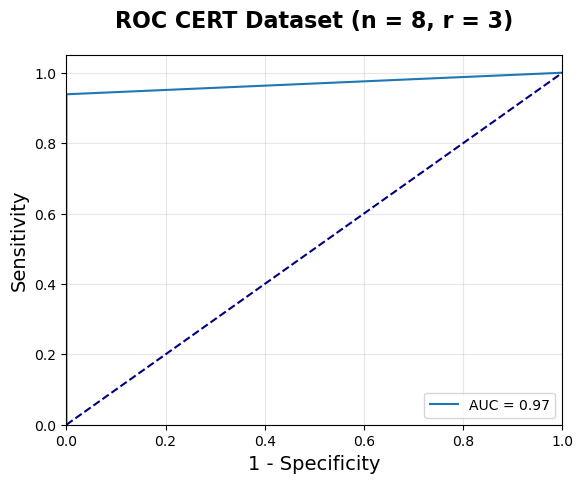

In [44]:
scores, labels = zip(*results)
x, y, _ = roc_curve(labels, scores)
auc_score = auc(x, y)
plt.plot(x, y, label=f'AUC = {auc_score:.2f}')


plt.plot([0, 1], [0, 1], color='navy', linestyle='--') 
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('1 - Specificity', fontsize=14)
plt.ylabel('Sensitivity', fontsize=14)
plt.title(f'ROC CERT Dataset (n = {N}, r = {R})', fontsize=16, fontweight='bold', pad=20)
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.show()

# Parameter Search

100%|██████████| 45508/45508 [10:13<00:00, 74.13it/s]


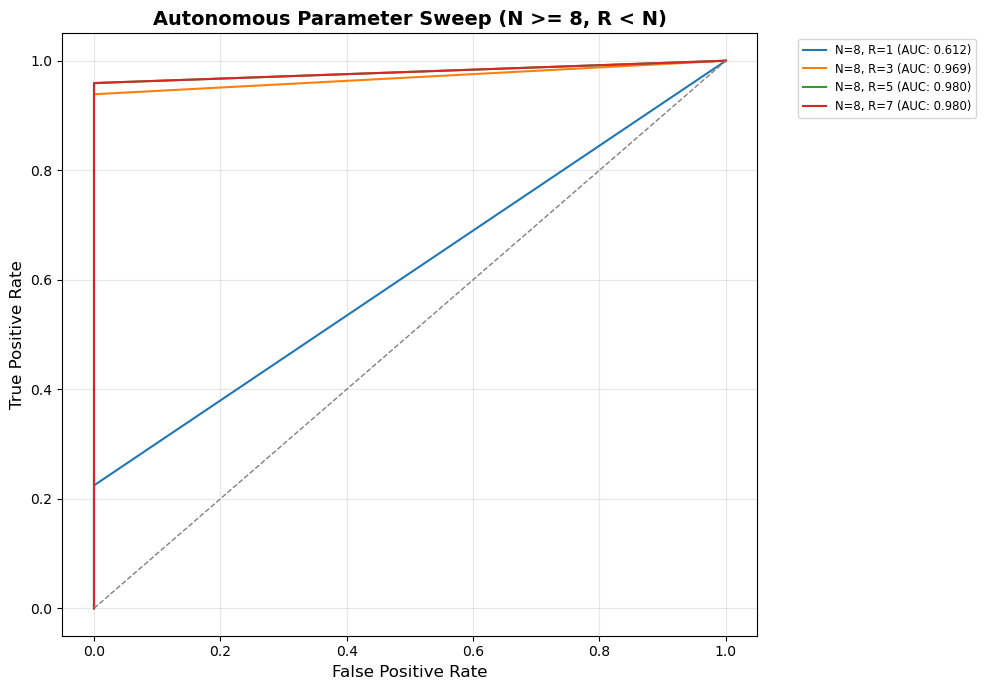


--- Summary of Results ---
N     | R     | AUC     
----------------------
8     | 5     | 0.9796
8     | 7     | 0.9796
8     | 3     | 0.9694
8     | 1     | 0.6122


In [ ]:
###########################################################################################################
###########################################################################################################
# -------------------------------------------- CHANGE THIS ONLY -------------------------------------------

# can be 'cert' or 'unm'
data_type = 'cert'

# can be '1', '2' or '3'
data_num = '1' 

# maximum value of N to test (starting from 8)
N_MAX = 8
assert N_MAX >= 8

# sampling interval for R values within the range [1, N)
R_STEP = 3
assert R_STEP < N_MAX
assert R_STEP >= 1

###########################################################################################################
###########################################################################################################

N_RANGE = range(8, N_MAX+1)
plt.figure(figsize=(10, 7))
auc_summary = []

for N in N_RANGE:
    for R in range(1, N, R_STEP):
        parameters = {
            'train': f"syscalls/snd-{data_type}/snd-{data_type}.train",
            'train_chunks': f"snd_{data_type}_train_chunks_N_{N}_R_{R}.txt",
            'train_chunks_unique': f"snd_{data_type}_train_unique_chunks_N_{N}_R_{R}.txt",
            'labels': f"syscalls/snd-{data_type}/snd-{data_type}.{data_num}.labels",
            'test': f"syscalls/snd-{data_type}/snd-{data_type}.{data_num}.test",
            'abc': f"file://syscalls/snd-{data_type}/snd-{data_type}.alpha",
            'chunks': f"snd_{data_type}_test{data_num}_chunks_N_{N}_R_{R}.txt",
            'mapping': f"snd_{data_type}_test{data_num}_mapping_N_{N}_R_{R}.txt"
        }

        results = pipeline(N, R, parameters)

        scores, labels = zip(*results)
        x, y, _ = roc_curve(labels, scores)
        auc_summary.append({'N': N, 'R': R, 'AUC': auc(x, y)})
        plt.plot(x, y, label=f'N={N}, R={R} (AUC: {auc(x,y):.3f})')

plt.plot([0, 1], [0, 1], color='gray', linestyle='--', lw=1)
plt.xlabel('1 - Specificity', fontsize=14)
plt.ylabel('Sensitivity', fontsize=14)
plt.title(f'ROC Results Dataset {data_type.upper()}-{data_num}', fontsize=18, fontweight='bold')

plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize='small')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("\n--- Summary of Results ---")
print(f"{'N':<5} | {'R':<5} | {'AUC':<8}")
print("-" * 22)
for res in sorted(auc_summary, key=lambda x: x['AUC'], reverse=True):
    print(f"{res['N']:<5} | {res['R']:<5} | {res['AUC']:.4f}")